---
title: "Forecasts Comparison"
date: 2026-03-04
description: "An introduction to the statistical tools for comparing forecast accuracy — the Diebold-Mariano test, the role of the loss function, and the Mincer-Zarnowitz regression as a calibration diagnostic."
categories: [Econometrics, Forecasting, Time Series]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Introduction

Suppose we observe a sequence of realizations $\{y_t\}_{t=1}^n$ and two competing forecasts $\{\hat{y}^A_t\}$ and $\{\hat{y}^B_t\}$. The goal is to determine which forecast is more accurate. A natural approach is to choose a loss function, compute the average loss for each forecast, and select the forecast with the lower average. This approach, while intuitive, raises two statistical issues.

**Issue 1 (sampling variability).** The difference in average loss is a random variable. A different out-of-sample period could produce a different ranking. We need a way to assess whether the observed difference is statistically significant.

**Issue 2 (serial dependence).** Forecast errors are often serially correlated, particularly when forecasts are produced from rolling or expanding estimation windows. This correlation inflates the variance of the average loss difference beyond what the standard independent and identically distributed (i.i.d.) formula would suggest.

The **Diebold-Mariano (DM) test** addresses both issues. It tests whether the mean loss differential between two forecasts is significantly different from zero, using a heteroskedasticity-and-autocorrelation-consistent (HAC) variance estimator to account for serial dependence.

A central theme of this post is that the DM test is only as informative as the loss function it operates on. Different loss functions penalize forecast errors in different ways, and changing the loss function can reverse the ranking of the same two forecasts. We illustrate this using squared error (SE) and quasi-likelihood (QLIKE) loss, two loss functions with very different weighting properties.

We then introduce the **Mincer-Zarnowitz (MZ) regression**, which answers a complementary question: is the forecast well calibrated? That is, does a one-unit increase in the forecast correspond, on average, to a one-unit increase in the realization? The MZ regression is a diagnostic tool that helps explain *why* two forecasts differ, but it does not replace the need to choose an appropriate loss function.


In [1]:
#| echo: false
#| output: false

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# ── Blog styling ────────────────────────────────────────────────────────
BLOG_PATH = Path("/Users/steveyang/Projects/Github/steveya.github.io")
sys.path.insert(0, str(BLOG_PATH))
from blog_styles import (
    apply_blog_plot_style,
    BLOG_PALETTE,
    style_results_table,
    inject_blog_table_css,
    blog_plot_context,
)

apply_blog_plot_style()
inject_blog_table_css()

# ── Reproducibility ─────────────────────────────────────────────────────
RNG = np.random.default_rng(42)

## 1. The Loss Function

Before comparing forecasts, we must specify what "accuracy" means. This is the role of the loss function.

**Definition.** A **loss function** $L(y_t, \hat{y}_t)$ maps a realization $y_t$ and a forecast $\hat{y}_t$ to a non-negative real number. Lower values of $L$ correspond to more accurate forecasts. The choice of $L$ encodes which types of forecast errors we consider most costly.

Three loss functions appear frequently in applied work:

| Loss | Formula | Emphasis |
|------|---------|--------------------|
| Squared Error (SE) | $L_{\text{SE}} = (y_t - \hat{y}_t)^2$ | Penalizes large absolute errors heavily. The squaring operation gives disproportionate weight to large deviations. |
| Absolute Error (AE) | $L_{\text{AE}} = \lvert y_t - \hat{y}_t \rvert$ | Penalizes absolute errors linearly, without the amplification from squaring. |
| Quasi-Likelihood (QLIKE) | $L_{\text{QLIKE}} = \dfrac{y_t}{\hat{y}_t} - \log\dfrac{y_t}{\hat{y}_t} - 1$ | Penalizes based on the ratio $y_t / \hat{y}_t$. It is especially useful for strictly positive targets and scale-sensitive forecasting problems. |

**Symmetry.** SE and AE are symmetric loss functions: over-predicting by $\delta$ incurs the same loss as under-predicting by $\delta$. QLIKE is asymmetric. To see this, fix $y_t = 1$:

- If $\hat{y}_t = 0.5$ (under-prediction by 50%), then $L_{\text{QLIKE}} \approx 0.307$.
- If $\hat{y}_t = 2.0$ (over-prediction by 100%), then $L_{\text{QLIKE}} \approx 0.193$.

Under-prediction is penalized more heavily. This asymmetry can be useful in applications where under-predicting a positive target is more consequential than over-predicting it. However, it also requires that forecasts remain strictly positive, since $L_{\text{QLIKE}} \to \infty$ as $\hat{y}_t \to 0$.

The following figure illustrates the loss surfaces of SE and QLIKE as functions of the forecast $\hat{y}_t$, with the true value fixed at $y_t = 1$:

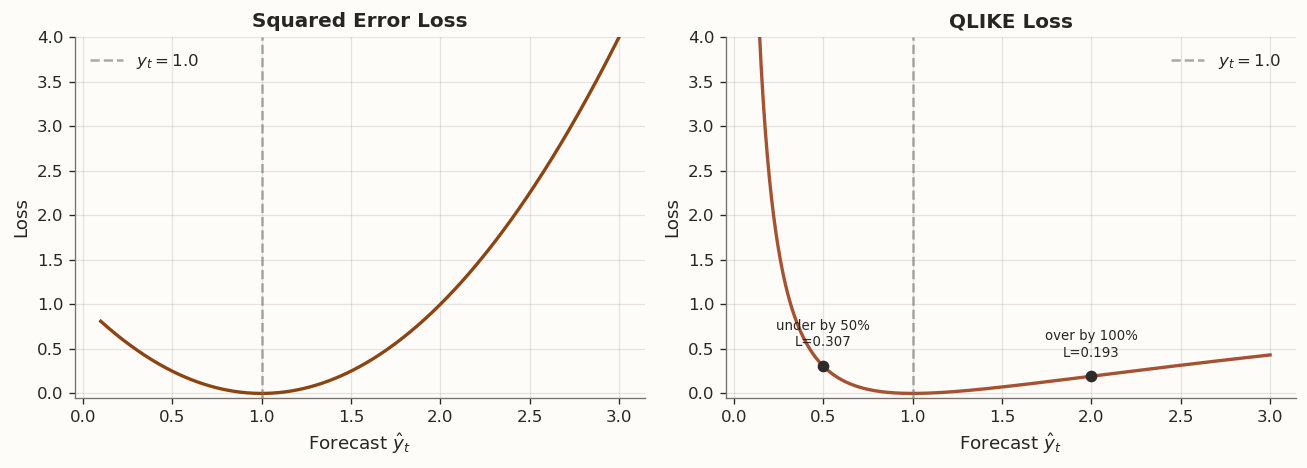

In [5]:
#| label: fig-loss-surfaces
#| code-fold: true
#| code-summary: "Plot: SE vs QLIKE loss surfaces"

y_true = 1.0
yhat = np.linspace(0.1, 3.0, 500)

se_loss = (y_true - yhat) ** 2
qlike_loss = y_true / yhat - np.log(y_true / yhat) - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(yhat, se_loss, color=BLOG_PALETTE[0], linewidth=2)
ax1.axvline(y_true, color=BLOG_PALETTE[3], linestyle="--", alpha=0.6, label=f"$y_t = {y_true}$")
ax1.set_xlabel("Forecast $\\hat{y}_t$")
ax1.set_ylabel("Loss")
ax1.set_title("Squared Error Loss", fontsize=12, fontweight="bold")
ax1.set_ylim(-0.05, 4)
ax1.legend()

ax2.plot(yhat, qlike_loss, color=BLOG_PALETTE[1], linewidth=2)
ax2.axvline(y_true, color=BLOG_PALETTE[3], linestyle="--", alpha=0.6, label=f"$y_t = {y_true}$")
ax2.set_xlabel("Forecast $\\hat{y}_t$")
ax2.set_ylabel("Loss")
ax2.set_title("QLIKE Loss", fontsize=12, fontweight="bold")
ax2.set_ylim(-0.05, 4)
ax2.legend()

# Mark asymmetry on QLIKE using the computed loss so labels cannot drift.
examples = [(0.5, "under by 50%", "bottom"), (2.0, "over by 100%", "bottom")]
for y_hat_ex, descriptor, va in examples:
    loss_val = y_true / y_hat_ex - np.log(y_true / y_hat_ex) - 1
    label = f"{descriptor}\nL={loss_val:.3f}"
    ax2.plot(y_hat_ex, loss_val, "o", color=BLOG_PALETTE[2], markersize=6)
    ax2.annotate(label, (y_hat_ex, loss_val), textcoords="offset points",
                 xytext=(0, 10), ha="center", va=va, fontsize=8)

fig.tight_layout()
plt.show()

### SE vs QLIKE: interpretation, sensitivity, and likelihood connections

Both SE and QLIKE are **consistent** loss functions for the conditional mean: each is uniquely minimized in expectation when $\hat{y}_t = \mathbb{E}[y_t \mid \mathcal{F}_{t-1}]$. We can verify this by computing the first-order condition. For SE, $\frac{\partial}{\partial \hat{y}}\,\mathbb{E}[(y_t - \hat{y})^2] = -2\,\mathbb{E}[y_t - \hat{y}] = 0$ gives $\hat{y} = \mathbb{E}[y_t]$. For QLIKE, $\frac{\partial}{\partial \hat{y}}\,\mathbb{E}\!\left[\frac{y_t}{\hat{y}} - \log\frac{y_t}{\hat{y}} - 1\right] = -\frac{\mathbb{E}[y_t]}{\hat{y}^2} + \frac{1}{\hat{y}} = 0$ gives $\hat{y} = \mathbb{E}[y_t]$. Both target the same object, but they weight forecast errors in fundamentally different ways.

#### What each loss measures

**SE measures absolute accuracy.** The loss $L_{\text{SE}} = (y_t - \hat{y}_t)^2$ grows as the square of the absolute error. A miss of 1.0 receives 100 times more loss than a miss of 0.1, regardless of the scale of $y_t$. The average SE across the evaluation sample is therefore dominated by observations where the absolute error is largest.

**QLIKE measures proportional accuracy.** The QLIKE loss can be written purely in terms of the ratio $r = y_t / \hat{y}_t$:

$$L_{\text{QLIKE}} = r - \log r - 1.$$

This loss depends only on how far $r$ departs from 1 — that is, on the proportional discrepancy between forecast and realization. A 50% over-prediction ($r = 0.5$) receives the same QLIKE loss whether $y_t = 10^{-4}$ or $y_t = 10^{-1}$. The same 50% over-prediction creates vastly different SE losses at those two scales. In the code below I sometimes use the algebraically equivalent form $\log \hat{y}_t + y_t/\hat{y}_t$, which differs from $L_{\text{QLIKE}}$ only by the observation-specific constants $-\log y_t - 1$ and therefore preserves forecast rankings and DM comparisons.

#### Sensitivity to extreme observations

Neither loss function is robust in the classical statistical sense of having a bounded influence function.

**SE has quadratic sensitivity.** For a fixed forecast $\hat{y}_t$, the SE loss grows as $O(y_t^2)$ when the realization is large. A single extreme observation can contribute more to the total SE than the rest of the sample combined. The influence of outliers is unbounded and grows faster than the outlier itself.

**QLIKE has linear sensitivity.** For a fixed forecast $\hat{y}_t$, the QLIKE loss grows as $O(y_t)$ when $y_t$ is large, since the dominant term is $y_t / \hat{y}_t$. This is still unbounded, so QLIKE is not robust in the Huber sense either. However, the growth rate is linear rather than quadratic, which makes QLIKE substantially less sensitive to extreme realizations than SE. In practice, when the forecast stays aligned with the scale of the target, the ratio $y_t / \hat{y}_t$ tends to stay moderate even on large observations, which further dampens the influence of extreme values.

**QLIKE has its own vulnerability.** While QLIKE is more stable for large $y_t$, it is fragile when $\hat{y}_t$ is close to zero. The term $\log \hat{y}_t \to -\infty$ as $\hat{y}_t \to 0$, so a forecast that severely underestimates a positive target incurs explosive QLIKE loss. Similarly, when $y_t = 0$, the ratio $y_t / \hat{y}_t = 0$ and the $\log$ term $-\log(y_t / \hat{y}_t)$ is undefined. In practice, both cases require a small floor on $y_t$ and $\hat{y}_t$ to keep computations well-defined.

This is the mirror image of SE's outlier problem: SE is dominated by extreme realizations; QLIKE is dominated by near-zero forecasts or realizations.

#### Likelihood connections

Both SE and QLIKE arise naturally as negative log-likelihoods, but under different statistical models.

**SE and the Gaussian level model.** Suppose $y_t = \hat{y}_t + \varepsilon_t$ with $\varepsilon_t \sim N(0, \sigma^2)$ for some constant $\sigma^2$. The log-likelihood for $\hat{y}_t$ given $y_t$ is, up to constants, $\ell = -\frac{1}{2\sigma^2}(y_t - \hat{y}_t)^2$. Minimizing average SE is therefore equivalent to maximum likelihood estimation (MLE) of the conditional mean under homoskedastic Gaussian noise.

**QLIKE and one important special case.** One prominent use of QLIKE is variance forecasting. If $r_t \mid \mathcal{F}_{t-1} \sim N(0, \sigma_t^2)$, then the log-likelihood for $\sigma_t^2$ given the observation $r_t^2$ is, up to constants,

$$\ell(\sigma_t^2) = -\frac{1}{2}\left[\log \sigma_t^2 + \frac{r_t^2}{\sigma_t^2}\right].$$

Minimizing the average QLIKE loss is equivalent to quasi-maximum likelihood estimation (QMLE) of the variance. This explains QLIKE's proportional weighting: likelihood-based inference for the variance naturally standardizes by the model's predicted scale, so a period of high variance is not automatically more influential than a period of low variance.

**Remark.** In short, SE is the MLE loss for the mean; QLIKE is the QMLE loss for the variance in this important special case. Neither is universally superior — each is the natural choice for a different estimation target.

#### Summary of the comparison

| Property | SE | QLIKE |
|----------|:--:|:-----:|
| Optimal forecast | $\mathbb{E}[y_t \mid \mathcal{F}_{t-1}]$ | $\mathbb{E}[y_t \mid \mathcal{F}_{t-1}]$ |
| Error concept | Absolute: $(y_t - \hat{y}_t)$ | Proportional: $y_t / \hat{y}_t$ |
| Growth in $y_t$ (fixed $\hat{y}_t$) | $O(y_t^2)$ — quadratic | $O(y_t)$ — linear |
| Main vulnerability | Extreme realizations dominate | Near-zero forecasts or realizations |
| Likelihood connection | MLE for the mean (Gaussian level model) | QMLE for the variance in the Gaussian variance model |
| Implicit weighting | High-variance observations get disproportionate weight | All observations weighted by proportional accuracy |

**Example.** The following simulation applies the same proportional forecast error to a target series with occasional spikes, and compares how SE and QLIKE distribute loss across observations:

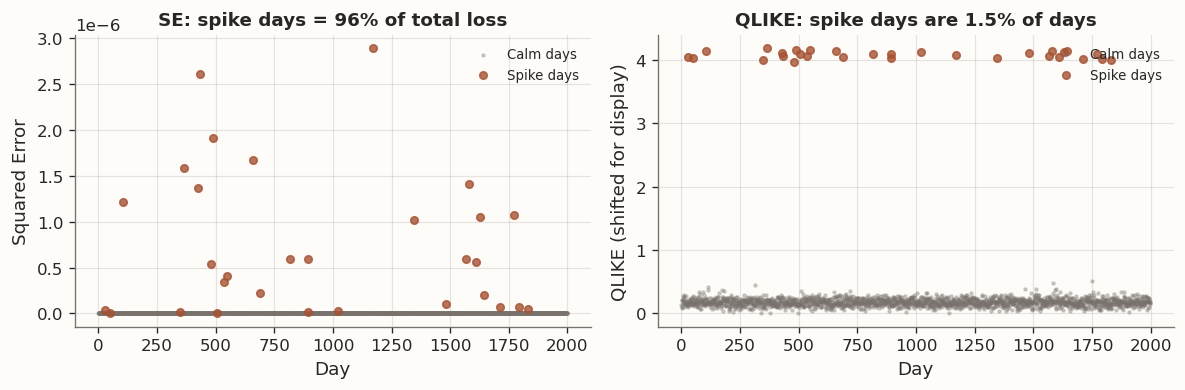

Spike days are 30/2000 = 1.5% of the sample
Under SE, they contribute 96% of total loss
Under centered QLIKE magnitudes, they contribute 46% of total variation
Interpretation: SE is dominated by spike days, while QLIKE is much closer to weighting days by proportional error.


In [6]:
#| label: scale-dependence-demo
#| fig-cap: "Spike days dominate SE rankings but not QLIKE"
#| code-fold: true
#| code-summary: "Scale-dependence: which days drive the ranking?"

n = 2000
rng = np.random.default_rng(123)

# Target: mostly calm, with occasional spikes (like daily variance)
is_spike = np.zeros(n, dtype=bool)
is_spike[rng.choice(n, size=30, replace=False)] = True

y = np.where(is_spike, 5e-3, 1e-4)  # spike days are 50x larger
y = y * rng.lognormal(mean=0, sigma=0.05, size=n)  # slight noise

# One forecast with 20% proportional noise (same % error on all days)
forecast = y * rng.lognormal(mean=0, sigma=0.2, size=n)

# Compute per-day SE and QLIKE
se = (y - forecast) ** 2
eps = 1e-20
ql = np.log(np.maximum(forecast, eps)) + y / np.maximum(forecast, eps)  # MLE form; differs from y/ŷ − log(y/ŷ) − 1 by a constant

# QLIKE above omits terms that are constant across forecasts for a given y_t.
# Those constants do not matter for ranking or DM comparisons.

se_spike_contribution = se[is_spike].sum() / se.sum() * 100

# Since QLIKE contains observation-specific constants, compare centered magnitudes
# rather than raw sums when discussing which days drive the picture.
ql_centered = ql - ql.mean()
ql_spike_contribution = np.abs(ql_centered[is_spike]).sum() / np.abs(ql_centered).sum() * 100

with blog_plot_context():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    # Left: per-day SE
    ax = axes[0]
    ax.scatter(np.where(~is_spike)[0], se[~is_spike], s=3, alpha=0.3, color=BLOG_PALETTE[3], label="Calm days")
    ax.scatter(np.where(is_spike)[0], se[is_spike], s=20, alpha=0.8, color=BLOG_PALETTE[1], label="Spike days", zorder=5)
    ax.set_ylabel("Squared Error")
    ax.set_xlabel("Day")
    ax.set_title(f"SE: spike days = {se_spike_contribution:.0f}% of total loss", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper right")

    # Right: per-day QLIKE
    ax = axes[1]
    ql_norm = ql - ql.min()  # Shift only for display.
    ax.scatter(np.where(~is_spike)[0], ql_norm[~is_spike], s=3, alpha=0.3, color=BLOG_PALETTE[3], label="Calm days")
    ax.scatter(np.where(is_spike)[0], ql_norm[is_spike], s=20, alpha=0.8, color=BLOG_PALETTE[1], label="Spike days", zorder=5)
    ax.set_ylabel("QLIKE (shifted for display)")
    ax.set_xlabel("Day")
    ax.set_title(f"QLIKE: spike days are {is_spike.sum()/n*100:.1f}% of days", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.show()

print(f"Spike days are {is_spike.sum()}/{n} = {is_spike.sum()/n*100:.1f}% of the sample")
print(f"Under SE, they contribute {se_spike_contribution:.0f}% of total loss")
print(f"Under centered QLIKE magnitudes, they contribute {ql_spike_contribution:.0f}% of total variation")
print("Interpretation: SE is dominated by spike days, while QLIKE is much closer to weighting days by proportional error.")

### Application: noisy proxies and variance forecasts

So far the discussion has been general. One setting where these forecast-comparison issues become especially important is variance forecasting, where the object of interest is latent and must be evaluated through a noisy proxy.

In many forecasting problems the true target is not directly observable. In volatility forecasting, the quantity of interest is the conditional variance $\sigma_t^2$, which is latent. What we observe instead is a noisy proxy such as the squared return $r_t^2$, which we decompose as

$$r_t^2 = \sigma_t^2 + \eta_t$$

for some noise term $\eta_t$ satisfying $\mathbb{E}[\eta_t \mid \mathcal{F}_{t-1}] = 0$. The mean-zero condition is essential: it ensures that the proxy is unbiased for the true target conditional on the information set available at forecast time.

This raises an important question: if Forecast A is genuinely better than Forecast B for predicting $\sigma_t^2$, does that ranking survive when we evaluate the forecasts using the noisy proxy $r_t^2$?

**Definition.** A loss function $L$ is called **robust to noise** (Patton, 2011) if the ranking of expected loss under the true target is preserved when the true target is replaced by an unbiased noisy proxy. Formally, if

$$\mathbb{E}[L(\sigma_t^2, \hat{y}^A_t)] \leq \mathbb{E}[L(\sigma_t^2, \hat{y}^B_t)]$$

then robustness requires

$$\mathbb{E}[L(r_t^2, \hat{y}^A_t)] \leq \mathbb{E}[L(r_t^2, \hat{y}^B_t)].$$

Both SE and QLIKE satisfy this robustness property, which is why both are widely used in the volatility-forecasting literature. However, robustness is an asymptotic statement about population rankings. In finite samples, the two loss functions can behave quite differently due to their different sensitivities to scale, as described above.

**Remark.** For variance forecasts evaluated against $r_t^2$, it is good practice to report DM test results under both SE and QLIKE:

::: {.callout-tip}
- If they agree, the conclusion is straightforward.
- If they disagree, QLIKE often deserves greater weight because it is less sensitive to a small number of extreme observations.
- The MZ regression (introduced in Section 4) can then help explain what kind of forecast difference is driving the divergence.
:::

## 2. The Diebold-Mariano Test

### Setup

Having chosen a loss function, we now formalize the question: is the difference in forecast accuracy statistically significant, or could it be attributable to sampling variability?

Let $n$ denote the number of out-of-sample observations. At each time $t$, Forecast A and Forecast B incur losses $L_A(y_t, \hat{y}^A_t)$ and $L_B(y_t, \hat{y}^B_t)$ respectively. Define the **loss differential**:

$$d_t = L_A(y_t, \hat{y}^A_t) - L_B(y_t, \hat{y}^B_t).$$

A positive value of $d_t$ indicates that Forecast A incurred greater loss at time $t$, so Forecast B performed better. The DM test evaluates the null hypothesis

$$H_0: \mathbb{E}[d_t] = 0 \quad \text{(equal predictive ability)}$$

against the two-sided alternative $H_1: \mathbb{E}[d_t] \neq 0$.

**Remark (one-sided tests).** In many applications we have a directional prior — for example, "is the new model better than the established benchmark?" In that case we test $H_1: \mathbb{E}[d_t] > 0$ (Forecast B is better). Using the same finite-sample $t_{n-1}$ approximation as below, the corresponding one-sided $p$-value is $p = 1 - F_{t_{n-1}}(\text{DM})$ instead of $p = 2\,[1 - F_{t_{n-1}}(|\text{DM}|)]$. The choice between one-sided and two-sided testing should be made before seeing the data.

### The naive approach and its failure

A first attempt is to construct a standard $t$-statistic. Compute the sample mean $\bar{d} = \frac{1}{n}\sum_{t=1}^n d_t$ and divide by the independent and identically distributed (i.i.d.) standard error $s_d / \sqrt{n}$, where $s_d^2 = \frac{1}{n-1}\sum_{t=1}^n (d_t - \bar{d})^2$.

This procedure is valid when the loss differentials $\{d_t\}$ are independent. In practice, however, they are typically **serially correlated**. Forecasts constructed from rolling or expanding estimation windows share a large fraction of their training data from one period to the next, inducing persistence in forecast errors and, consequently, in the loss differential sequence.

Serial correlation alters the variance of $\bar{d}$. With positive autocorrelation, consecutive observations carry redundant information, so the effective sample size is smaller than $n$. The naive i.i.d. formula understates the true variance of $\bar{d}$, producing a test statistic that is too large in magnitude. The result is an inflated rejection rate — the test rejects $H_0$ too often, even when it is true.

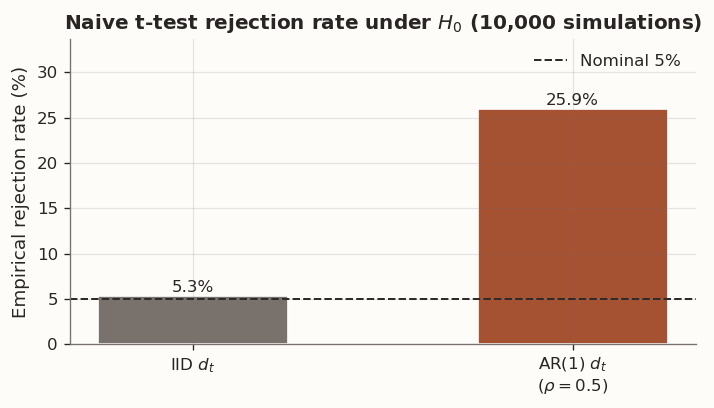

In [7]:
#| label: autocorrelation-inflation
#| fig-cap: "Serial correlation in the loss differential inflates the naive test statistic"

# --- Generate autocorrelated loss differentials (AR(1)) ---
n = 500
rho = 0.5  # AR(1) coefficient
d_iid = RNG.normal(0, 1, n)  # under H0, true mean = 0
d_ar = np.empty(n)
d_ar[0] = d_iid[0]
for t in range(1, n):
    d_ar[t] = rho * d_ar[t - 1] + d_iid[t]

# Naive t-stat
naive_t_iid = d_iid.mean() / (d_iid.std(ddof=1) / np.sqrt(n))
naive_t_ar = d_ar.mean() / (d_ar.std(ddof=1) / np.sqrt(n))

# --- Monte Carlo: size under null H0 ---
n_sims = 10_000
naive_rejections_iid = 0
naive_rejections_ar = 0

for _ in range(n_sims):
    eps = RNG.normal(0, 1, n)
    # IID case
    t_stat = eps.mean() / (eps.std(ddof=1) / np.sqrt(n))
    if abs(t_stat) > 1.96:
        naive_rejections_iid += 1
    # AR case
    d = np.empty(n)
    d[0] = eps[0]
    for t in range(1, n):
        d[t] = rho * d[t - 1] + eps[t]
    t_stat = d.mean() / (d.std(ddof=1) / np.sqrt(n))
    if abs(t_stat) > 1.96:
        naive_rejections_ar += 1

size_iid = naive_rejections_iid / n_sims
size_ar = naive_rejections_ar / n_sims

with blog_plot_context():
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.bar(
        ["IID $d_t$", f"AR(1) $d_t$\n($\\rho = {rho}$)"],
        [size_iid * 100, size_ar * 100],
        color=[BLOG_PALETTE[3], BLOG_PALETTE[1]],
        width=0.5,
        edgecolor="white",
    )
    ax.axhline(5.0, color=BLOG_PALETTE[2], ls="--", lw=1.2, label="Nominal 5%")
    ax.set_ylabel("Empirical rejection rate (%)")
    ax.set_title("Naive t-test rejection rate under $H_0$ (10,000 simulations)")
    ax.legend(frameon=False)
    for bar, val in zip(bars, [size_iid, size_ar]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val*100:.1f}%",
            ha="center",
            fontsize=10,
        )
    ax.set_ylim(0, max(size_iid, size_ar) * 100 * 1.3)
    plt.tight_layout()
    plt.show()

### HAC (Newey-West) variance

Diebold and Mariano (1995) solve the serial-correlation problem by replacing the naive variance with a **heteroskedasticity and autocorrelation consistent (HAC)** estimator. The key idea is to estimate the variance of $\bar{d}$ while allowing for dependence between nearby observations.

**Step 1: Sample autocovariances.** Define the sample autocovariance of the loss differential at lag $k$:

$$\hat{\gamma}_k = \frac{1}{n} \sum_{t=k+1}^{n} (d_t - \bar{d})(d_{t-k} - \bar{d}).$$

**Step 2: Bartlett kernel weighting.** If the dependence structure dies off at higher lags, distant autocovariances should be downweighted. The Newey-West estimator achieves this through the Bartlett kernel:

$$\widehat{\text{Var}}(\bar{d}) = \frac{1}{n}\left[\hat{\gamma}_0 + 2\sum_{k=1}^{M} \left(1 - \frac{k}{M+1}\right)\hat{\gamma}_k\right]$$

where $M$ is the truncation lag (bandwidth). The Bartlett weights $w_k = 1 - k/(M+1)$ decrease linearly from 1 to 0 as $k$ increases from 1 to $M$, and autocovariances beyond lag $M$ receive zero weight.

**Step 3: Bandwidth selection.** A common automatic rule for the truncation lag is

$$M = \left\lfloor 4\left(\frac{n}{100}\right)^{2/9} \right\rfloor.$$

This rule is a practical default that works well for the sample sizes encountered in out-of-sample forecast evaluation.

**The DM statistic.** The test statistic is

$$\text{DM} = \frac{\bar{d}}{\sqrt{\widehat{\text{Var}}(\bar{d})}} \xrightarrow{d} N(0,1).$$

Under the null hypothesis, DM is asymptotically standard normal. In finite samples, it is common to compare this statistic with the $t_{n-1}$ distribution. A positive and significant DM statistic indicates that Forecast A has higher average loss, hence Forecast B is preferred under the chosen loss function.

**Remark (Harvey-Leybourne-Newbold correction).** Harvey, Leybourne, and Newbold (1997) proposed a small-sample correction that improves the finite-sample size of the DM test. The corrected statistic is

$$\text{DM}^* = \text{DM} \cdot \left[\frac{n + 1 - 2M + M(M-1)/n}{n}\right]^{1/2}$$

and is compared with the $t_{n-1}$ distribution. The correction shrinks the statistic toward zero and matters most when $n$ is small relative to the bandwidth $M$. In large samples, $\text{DM}^* \approx \text{DM}$. For simplicity, the implementation below reports the uncorrected HAC DM statistic; the HLN adjustment is a useful finite-sample refinement rather than a requirement for the examples in this post.

In [2]:
#| label: dm-implementation
#| code-fold: show

from scipy import stats


def dm_test_from_scratch(loss_a, loss_b, max_lag=None):
    """Minimal DM test with Newey-West HAC variance."""
    d = np.asarray(loss_a) - np.asarray(loss_b)
    n = len(d)
    d_bar = d.mean()

    # Automatic bandwidth rule of thumb. We enforce at least one lag so the
    # function behaves sensibly in short samples.
    if max_lag is None:
        max_lag = int(np.floor(4 * (n / 100) ** (2 / 9)))
    max_lag = max(1, max_lag)

    # Sample autocovariances of the demeaned loss differential.
    d_demean = d - d_bar
    gamma = np.array(
        [np.dot(d_demean[k:], d_demean[: n - k]) / n for k in range(max_lag + 1)]
    )

    # Newey-West HAC variance using Bartlett weights.
    var_d_bar = (
        gamma[0]
        + 2 * sum((1 - k / (max_lag + 1)) * gamma[k] for k in range(1, max_lag + 1))
    ) / n

    if var_d_bar <= 0:
        return {"dm_stat": np.nan, "p_value": np.nan, "max_lag": max_lag, "n": n}

    dm_stat = d_bar / np.sqrt(var_d_bar)
    p_value = 2 * stats.t.sf(abs(dm_stat), df=n - 1)
    return {"dm_stat": dm_stat, "p_value": p_value, "max_lag": max_lag, "n": n}

In [8]:
#| label: dm-synthetic-demo

# --- Synthetic forecasting experiment ---
n = 500
sigma2_true = np.exp(0.5 * np.cumsum(RNG.normal(0, 0.05, n)))  # log-normal vol path
y = sigma2_true + RNG.normal(0, 0.3, n) * np.sqrt(sigma2_true)  # noisy proxy

# Forecast A: mildly biased, low noise (better)
yhat_a = sigma2_true * 1.0 + RNG.normal(0, 0.1, n) * np.sqrt(sigma2_true)
# Forecast B: more biased, higher noise (worse)
yhat_b = sigma2_true * 1.15 + RNG.normal(0, 0.2, n) * np.sqrt(sigma2_true)

# Compute losses
se_a = (y - yhat_a) ** 2
se_b = (y - yhat_b) ** 2

# DM test
result = dm_test_from_scratch(se_a, se_b)

print(f"Sample size:    n = {result['n']}")
print(f"Bandwidth:      M = {result['max_lag']}")
print(f"DM statistic:   {result['dm_stat']:.3f}")
print(f"p-value:        {result['p_value']:.4f}")
print()
if result["p_value"] < 0.05:
    winner = "B" if result["dm_stat"] > 0 else "A"
    print(f"→ Reject H₀ at 5%: Forecast {winner} is significantly better.")
else:
    print("→ Cannot reject H₀: no significant difference at 5%.")

Sample size:    n = 500
Bandwidth:      M = 5
DM statistic:   -8.771
p-value:        0.0000

→ Reject H₀ at 5%: Forecast A is significantly better.


### Power depends on sample size

Even when one forecast is genuinely superior, the DM test may fail to reject $H_0$ if the evaluation sample is too short. This is the standard problem of statistical power: small samples make real effects difficult to detect.

The following simulation holds the effect size fixed and varies the out-of-sample size $n$. To isolate the role of sample size, we generate the loss differential $d_t$ directly from a first-order autoregressive [AR(1)] process with positive mean, rather than constructing two complete forecast-and-loss series.

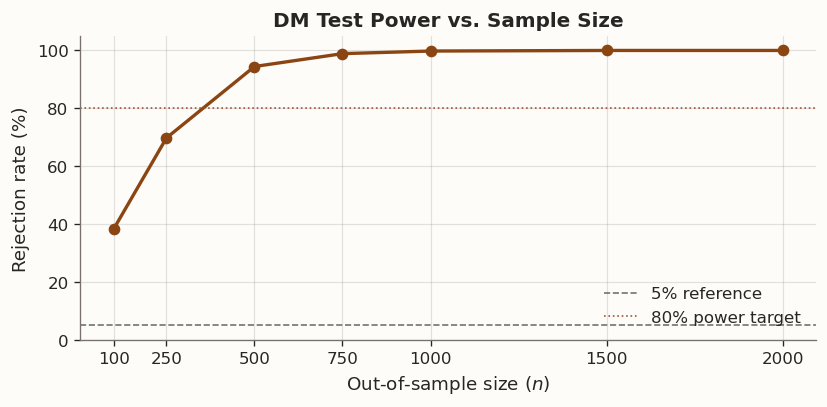

In [4]:
#| label: power-analysis
#| fig-cap: "DM test power increases with sample size"

sample_sizes = [100, 250, 500, 750, 1000, 1500, 2000]
n_sims = 2_000
power = []

for n in sample_sizes:
    rejections = 0
    for _ in range(n_sims):
        # Here we simulate the loss differential d_t directly rather than
        # generating two separate non-negative loss series.
        mu = 0.15  # innovation mean in the AR(1) loss-differential process
        rho = 0.3
        eps = RNG.normal(mu, 1, n)
        d = np.empty(n)
        d[0] = eps[0]
        for t in range(1, n):
            d[t] = rho * d[t - 1] + eps[t]

        loss_a = d
        loss_b = np.zeros(n)
        res = dm_test_from_scratch(loss_a, loss_b)
        if not np.isnan(res["p_value"]) and res["p_value"] < 0.05 and res["dm_stat"] > 0:
            rejections += 1
    power.append(rejections / n_sims)

with blog_plot_context():
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(sample_sizes, [p * 100 for p in power], "o-", color=BLOG_PALETTE[0], lw=2, markersize=6)
    ax.axhline(5, color=BLOG_PALETTE[3], ls="--", lw=1, label="5% reference")
    ax.axhline(80, color=BLOG_PALETTE[1], ls=":", lw=1, label="80% power target")
    ax.set_xlabel("Out-of-sample size ($n$)")
    ax.set_ylabel("Rejection rate (%)")
    ax.set_title("DM Test Power vs. Sample Size")
    ax.set_xticks(sample_sizes)
    ax.grid(True, alpha=0.2)
    ax.legend(frameon=False, loc="lower right")
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

## 3. When the Loss Function Reverses the Ranking

We now combine the results of the preceding sections. Since different loss functions penalize different types of forecast errors, and the DM test compares forecasts under the chosen loss, it is possible for the same pair of forecasts to produce opposite DM conclusions under SE and QLIKE.

### Simulation design

We simulate data from a GARCH(1,1) process and construct two forecasts of the conditional variance $\sigma_t^2$. Both forecasts are centered on the true variance, but they introduce errors with different structures:

- **Forecast A ("proportional noise")**: $\hat{y}^A_t = \sigma_t^2 M_t$, where $M_t$ is a mean-one lognormal multiplier independent of $\sigma_t^2$. The forecast errors scale with the level of volatility: larger absolute errors on high-variance days, but relatively stable forecast-to-realization ratios across all scales.

- **Forecast B ("additive noise")**: $\hat{y}^B_t = \sigma_t^2 + c\,\varepsilon_t$, where $c > 0$ is a fixed constant and $\varepsilon_t \sim N(0,1)$. The forecast errors have approximately constant absolute magnitude regardless of the variance level. This yields smaller absolute errors on high-variance days, but potentially large ratio distortions when the true variance is small.

**Prior expectation.** Based on the properties of SE and QLIKE established in Section 1:

- SE should favor Forecast B, because B produces smaller absolute errors on high-variance days, and SE gives disproportionate weight to those observations.
- QLIKE should favor Forecast A, because A maintains more stable forecast-to-realization ratios across all scales, which is what QLIKE rewards.

The DM test results confirm this:

In [9]:
#| label: loss-flip-simulation

# Use a local RNG so results are independent of upstream cells
rng_flip = np.random.default_rng(42)

# --- GARCH(1,1) DGP ---
omega_g, alpha_g, beta_g = 0.00001, 0.08, 0.90
n_total = 4000
n_burn = 500
n = n_total - n_burn

sigma2 = np.empty(n_total)
garch_eps = rng_flip.normal(size=n_total)
sigma2[0] = omega_g / (1 - alpha_g - beta_g)

for t in range(1, n_total):
    sigma2[t] = omega_g + alpha_g * garch_eps[t - 1] ** 2 * sigma2[t - 1] + beta_g * sigma2[t - 1]

sigma2_os = sigma2[n_burn:]
r2_os = sigma2_os * garch_eps[n_burn:] ** 2

# --- Two forecasts with different noise structures ---
# Forecast A: proportional noise, mean-corrected so E[M_t] = 1.
sigma_a = 0.35
yhat_a = sigma2_os * np.exp(sigma_a * rng_flip.normal(size=n) - sigma_a**2 / 2)
yhat_a = np.maximum(yhat_a, 1e-12)

# Forecast B: additive noise with fixed scale.
noise_b_scale = 0.20 * np.sqrt(np.mean(sigma2_os**2))
yhat_b_raw = sigma2_os + noise_b_scale * rng_flip.normal(size=n)
n_negative_b = int((yhat_b_raw <= 0).sum())
yhat_b = np.maximum(yhat_b_raw, 1e-12)

# --- Evaluate losses against the noisy proxy r^2 ---
se_a = (r2_os - yhat_a) ** 2
se_b = (r2_os - yhat_b) ** 2

r2_safe = np.maximum(r2_os, 1e-20)

# We drop the terms -log(r2_safe) - 1 from QLIKE because they are the same
# for both forecasts at a given time t, so they do not affect ranking or DM.
ql_a = np.log(yhat_a) + r2_safe / yhat_a  # MLE form (ranking-equivalent)
ql_b = np.log(yhat_b) + r2_safe / yhat_b

# --- DM tests ---
dm_se = dm_test_from_scratch(se_a, se_b)
dm_ql = dm_test_from_scratch(ql_a, ql_b)

print(f"Forecast B produced {n_negative_b} non-positive raw forecasts before flooring.")
print("These are floored at 1e-12 because QLIKE is only defined for positive forecasts.")
print(f"SE test:     DM = {dm_se['dm_stat']:.4f}, p-value = {dm_se['p_value']:.4f}")
print(f"QLIKE test:  DM = {dm_ql['dm_stat']:.4f}, p-value = {dm_ql['p_value']:.4f}")

# Results table
results = pd.DataFrame({
    "Loss function": ["SE", "QLIKE"],
    "DM statistic": [dm_se["dm_stat"], dm_ql["dm_stat"]],
    "p-value": [dm_se["p_value"], dm_ql["p_value"]],
    "Better forecast": [
        "B (additive)" if dm_se["dm_stat"] > 0 and dm_se["p_value"] < 0.05 else ("A (proportional)" if dm_se["dm_stat"] < 0 and dm_se["p_value"] < 0.05 else "No sig. diff."),
        "B (additive)" if dm_ql["dm_stat"] > 0 and dm_ql["p_value"] < 0.05 else ("A (proportional)" if dm_ql["dm_stat"] < 0 and dm_ql["p_value"] < 0.05 else "No sig. diff."),
    ],
}).set_index("Loss function")

style_results_table(results, precision=4, index_col="Loss function")

Forecast B produced 11 non-positive raw forecasts before flooring.
These are floored at 1e-12 because QLIKE is only defined for positive forecasts.
SE test:     DM = 3.4616, p-value = 0.0005
QLIKE test:  DM = -2.1822, p-value = 0.0292


,DM statistic,p-value,Better forecast
Loss function,,,
SE,3.4616,0.0005,B (additive)
QLIKE,-2.1822,0.0292,A (proportional)


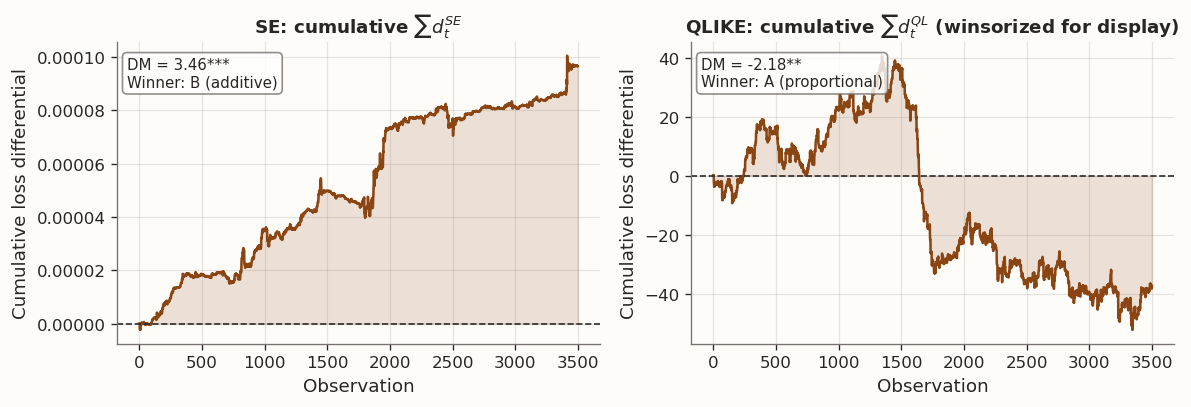

For display, 2.0% of QLIKE differentials were winsorized at the 1st/99th percentiles.
The statistical test itself used the raw, unwinsorized QLIKE differential.


In [10]:
#| label: loss-flip-plot
#| fig-cap: "Cumulative loss differentials under SE and QLIKE - opposite trends"

with blog_plot_context():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    d_se_raw = se_a - se_b
    d_ql_raw = ql_a - ql_b

    # Winsorize only for display. The DM test above used the raw differential.
    # This keeps a few extreme QLIKE observations from dominating the plot scale.
    lo, hi = np.percentile(d_ql_raw, [1, 99])
    d_ql_clip = np.clip(d_ql_raw, lo, hi)
    clip_share = np.mean(d_ql_raw != d_ql_clip) * 100

    for ax, d, title, dm_res in zip(
        axes,
        [d_se_raw, d_ql_clip],
        ["SE: cumulative $\\sum d_t^{SE}$", "QLIKE: cumulative $\\sum d_t^{QL}$ (winsorized for display)"],
        [dm_se, dm_ql],
    ):
        cumsum = np.cumsum(d)
        ax.plot(cumsum, color=BLOG_PALETTE[0], lw=1.5)
        ax.axhline(0, color=BLOG_PALETTE[2], ls="--", lw=1)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Observation")
        ax.set_ylabel("Cumulative loss differential")
        ax.fill_between(range(len(cumsum)), 0, cumsum, alpha=0.15, color=BLOG_PALETTE[0])

        sig = "***" if dm_res["p_value"] < 0.01 else ("**" if dm_res["p_value"] < 0.05 else "")
        winner = "A (proportional)" if dm_res["dm_stat"] < 0 else "B (additive)"
        ax.text(
            0.02, 0.95,
            f"DM = {dm_res['dm_stat']:.2f}{sig}\nWinner: {winner}",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=BLOG_PALETTE[3], alpha=0.8),
        )

    plt.tight_layout()
    plt.show()

print(f"For display, {clip_share:.1f}% of QLIKE differentials were winsorized at the 1st/99th percentiles.")
print("The statistical test itself used the raw, unwinsorized QLIKE differential.")

### Interpretation

The reversal is a direct consequence of how SE and QLIKE weight forecast errors differently.

**Forecast A (proportional noise)** produces errors that grow with $\sigma_t^2$. On high-variance days, its absolute errors are large, and since SE squares the absolute error, those days dominate the SE comparison. Hence A loses under SE.

**Forecast B (additive noise)** produces errors of roughly constant absolute size. On high-variance days, a fixed additive disturbance is small relative to the target, so B performs well under SE, yet on low-variance days the ratio $\hat{y}_B / y_t$ can become severely distorted. Since QLIKE evaluates accuracy through these ratios, B loses under QLIKE.

The following table summarizes the mechanism:

| | SE | QLIKE |
|--|:--:|:-----:|
| **Primary emphasis** | Absolute error magnitude | Forecast-to-realization ratio |
| **Observations with greatest influence** | High-variance days with large absolute misses | Days with large proportional distortion |
| **Winner in this simulation** | B (smaller absolute errors on volatile days) | A (more stable ratios across all scales) |

**Remark.** Neither result is incorrect. The two loss functions answer different forecasting questions. This is why a DM test result is incomplete without specifying which loss function was used and why that loss function is appropriate for the application at hand.

## 4. The Mincer-Zarnowitz Regression

The DM test determines which forecast has lower expected loss under a given criterion. It does **not** characterize the nature of the forecast errors. The **Mincer-Zarnowitz (MZ) regression** serves this complementary diagnostic purpose by examining forecast calibration.

### Setup

**Definition.** The Mincer-Zarnowitz regression is the ordinary least squares (OLS) regression of the realized target on the forecast:

$$y_t = \alpha + \beta\,\hat{y}_t + \varepsilon_t.$$

The estimated coefficients $(\hat{\alpha}, \hat{\beta})$ and the coefficient of determination $R^2$ provide three diagnostic indicators:

| Parameter | Ideal value | Interpretation |
|-----------|:-----------:|----------------|
| $\alpha$ | 0 | No systematic level bias |
| $\beta$ | 1 | A one-unit increase in the forecast corresponds, on average, to a one-unit increase in the realization |
| $R^2$ | 1 | The forecast explains all variation in the realized target |

These are diagnostic benchmarks, not binary pass/fail conditions. Common patterns of miscalibration include:

- **$\beta > 1$**: the forecast **under-reacts**. Realized movements are larger than the forecast movements suggest.
- **$\beta < 1$**: the forecast **over-reacts**. The forecast exhibits larger swings than the realizations warrant.
- **$\alpha \neq 0$ with $\beta \approx 1$**: the forecast has a **level bias** — it is systematically too high or too low.
- **Low $R^2$**: the forecast may be directionally correct but explains little of the variation in the realized target.

**Joint calibration test.** Rather than inspecting $\alpha$ and $\beta$ individually, we can test them jointly with the null hypothesis $H_0: (\alpha, \beta) = (0, 1)$ using a standard Wald or $F$-test. Rejection indicates that the forecast is miscalibrated in at least one dimension.

**Remark (standard errors).** The standard errors from classical OLS are valid only when the residuals $\varepsilon_t$ are serially uncorrelated and homoskedastic. In forecast evaluation, residuals are often autocorrelated — for example, overlapping forecast horizons guarantee it. In such cases, HAC (Newey-West) standard errors should be used for both the individual $t$-tests and the joint Wald test.

The MZ regression characterizes the *structure* of forecast errors. It is a calibration diagnostic, not a substitute for a loss-based forecast comparison.

Forecast A:  α = 2.39e-04,  β = 0.501,  R² = 0.042
  Joint Wald test H₀: (α,β)=(0,1):  χ² = 153.34,  p = 0.0000
Forecast B:  α = 1.42e-04,  β = 0.706,  R² = 0.059
  Joint Wald test H₀: (α,β)=(0,1):  χ² = 37.91,  p = 0.0000

Note: standard errors are classical OLS (not HAC-robust).


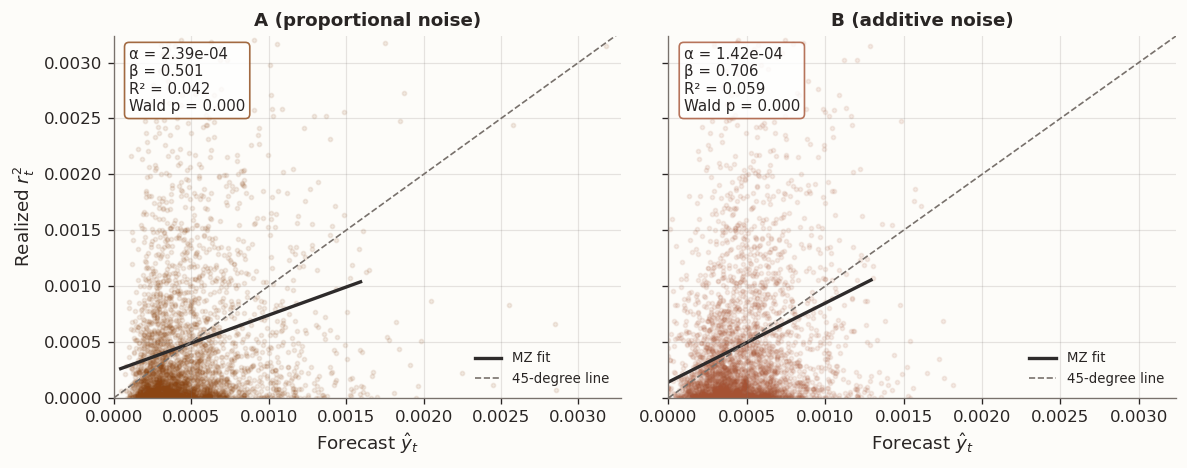

In [11]:
#| label: mz-demo
#| fig-cap: "MZ regression for the two forecasts from Section 3"

def mz_regression(y, yhat):
    """OLS: y = alpha + beta * yhat + eps, with joint Wald test."""
    X = np.column_stack([np.ones(len(yhat)), yhat])
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_pred = X @ beta
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    n_obs = len(y)
    sigma2_hat = ss_res / (n_obs - 2)
    cov_beta = sigma2_hat * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov_beta))
    t_stats = beta / se

    # Joint Wald test: H0: (alpha, beta) = (0, 1)
    r = beta - np.array([0.0, 1.0])  # deviation from null
    wald_stat = r @ np.linalg.inv(cov_beta) @ r
    wald_p = 1 - stats.chi2.cdf(wald_stat, df=2)

    return {
        "alpha": beta[0],
        "beta": beta[1],
        "se_alpha": se[0],
        "se_beta": se[1],
        "t_alpha": t_stats[0],
        "t_beta": t_stats[1],
        "r2": r2,
        "wald_stat": wald_stat,
        "wald_p": wald_p,
        "y_pred": y_pred,
    }

# Use r2_os (proxy), yhat_a, yhat_b from Section 3
mz_a = mz_regression(r2_os, yhat_a)
mz_b = mz_regression(r2_os, yhat_b)

# Print MZ results
for label, mz in [("Forecast A", mz_a), ("Forecast B", mz_b)]:
    print(f"{label}:  α = {mz['alpha']:.2e},  β = {mz['beta']:.3f},  R² = {mz['r2']:.3f}")
    print(f"  Joint Wald test H₀: (α,β)=(0,1):  χ² = {mz['wald_stat']:.2f},  p = {mz['wald_p']:.4f}")
print()
print("Note: standard errors are classical OLS (not HAC-robust).")

with blog_plot_context():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, yhat, mz, label, color in zip(
        axes, [yhat_a, yhat_b], [mz_a, mz_b],
        ["A (proportional noise)", "B (additive noise)"],
        [BLOG_PALETTE[0], BLOG_PALETTE[1]],
    ):
        ax.scatter(yhat, r2_os, alpha=0.1, s=6, color=color, rasterized=True)

        # MZ fit line
        x_range = np.linspace(max(yhat.min(), 0), np.percentile(yhat, 99), 100)
        ax.plot(x_range, mz["alpha"] + mz["beta"] * x_range, color=BLOG_PALETTE[2], lw=2, label="MZ fit")

        # 45-degree line = perfect calibration benchmark
        lim = np.percentile(np.concatenate([yhat, r2_os]), 99) * 1.1
        ax.plot([0, lim], [0, lim], "--", color=BLOG_PALETTE[3], lw=1, label="45-degree line")

        ax.set_title(label, fontsize=11)
        ax.set_xlabel("Forecast $\\hat{y}_t$")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.text(
            0.03, 0.97,
            f"α = {mz['alpha']:.2e}\nβ = {mz['beta']:.3f}\nR² = {mz['r2']:.3f}\nWald p = {mz['wald_p']:.3f}",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8),
        )
        ax.legend(frameon=False, loc="lower right", fontsize=8)

    axes[0].set_ylabel("Realized $r_t^2$")
    plt.tight_layout()
    plt.show()

### Connecting MZ to the DM divergence

The MZ regression helps explain *what kind of forecast errors* produced the divergent DM results in Section 3. However, it does not determine which loss function is appropriate for the application.

- **Forecast B** (additive noise) has a higher $\beta$ and higher $R^2$. In terms of calibration, it tracks large realized movements more closely. This is consistent with the SE result: SE rewards small absolute errors on high-variance days, precisely where Forecast B excels.

- **Forecast A** (proportional noise) has a lower $\beta$ and lower $R^2$ because its absolute errors are larger. However, its forecast-to-realization ratios are more stable across scales, which is the property that QLIKE rewards.

The MZ regression thus provides a structural explanation for the DM disagreement. The two diagnostics are complementary: MZ describes the calibration properties of each forecast, while DM evaluates overall accuracy under a specific loss criterion.

::: {.callout-note}
**Recommended workflow for forecast evaluation:**

1. Choose the loss function based on the application requirements, not based on which forecast you expect to win.
2. Run the DM test under that loss function (applying the HLN correction if $n$ is small).
3. If SE and QLIKE disagree, report both results rather than selectively reporting the favorable one.
4. Use the MZ regression — including the joint test $H_0: (\alpha, \beta) = (0,1)$ with HAC standard errors — to diagnose whether the disagreement arises from bias, reaction strength, or residual noise.
5. Present the full set of evidence: DM(SE), DM(QLIKE), and the MZ parameters.
:::

## Summary

The main results of this post are as follows.

1. **The loss function is a modeling choice.** SE and QLIKE are both consistent for the conditional mean, but they measure different properties of forecast accuracy. SE emphasizes absolute accuracy and gives disproportionate weight to large-scale observations. QLIKE emphasizes proportional accuracy across all scales. Both have likelihood connections, and changing the loss function can change the DM winner because it changes the definition of what constitutes a costly forecast error.

2. **The DM test requires HAC standard errors.** Loss differentials are typically serially correlated when forecasts are built from rolling or expanding windows. The naive i.i.d. standard error understates the true uncertainty, inflating the rejection rate. The Newey-West HAC estimator corrects for this dependence, and the Harvey-Leybourne-Newbold correction further improves finite-sample behavior.

3. **QLIKE is often informative for positive, scale-sensitive targets.** When the target variable spans several orders of magnitude, SE can be dominated by a small number of extreme observations. QLIKE provides a more balanced evaluation by weighting observations through proportional accuracy rather than absolute error magnitude. Variance forecasting is one important example of this setting.

4. **The MZ regression characterizes forecast calibration, not the preferred loss function.** The MZ parameters ($\alpha$, $\beta$, $R^2$) and the joint test of $H_0: (\alpha, \beta) = (0, 1)$ describe the systematic relationship between forecasts and realizations. They are useful for diagnosing *why* two forecasts differ, but they do not determine which forecast is more accurate — that requires a loss-based comparison. When using MZ in a forecasting context, HAC standard errors should replace the classical OLS ones.

5. **A thorough forecast comparison reports multiple diagnostics.** The recommended practice is to choose a loss function appropriate for the application, run the DM test, and use the MZ regression to understand the mechanism behind the result. When SE and QLIKE disagree, reporting both results provides useful information about the nature of the forecast differences.

For a worked example applying these tools to a volatility-forecasting setting, see the companion post on [volatility forecasting with XGBSTES](../volatility-forecasts-4/index.html).